# 01. What Is a Causal Question?

Causal inference begins before any model is fit. The first task is to state the question in a way that makes the decision, intervention, comparison, outcome, population, and time horizon explicit.

A causal question asks:

> What would change in an outcome if we changed an action, policy, treatment, exposure, or system behavior for a well-defined group of units?

That is different from asking whether two variables move together, or whether one variable helps predict another. Those questions can be useful, but they are not yet causal.

In industry settings, this distinction is the difference between a dashboard insight and an action recommendation. A dashboard may say that customers who receive a retention offer have higher 30-day spend. A causal analysis asks whether sending the offer itself would increase 30-day profit if the company changed the offer policy.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Distinguish descriptive, predictive, and causal questions.
2. Rewrite vague business questions as causal questions.
3. Identify the units, treatment, comparison, outcome, time horizon, target population, and estimand in a causal question.
4. Explain why association is not enough for intervention decisions.
5. Use a simple simulation to see how selection bias can create a large difference between an observed association and a true causal effect.
6. Explain the roles of an estimand, estimator, and estimate.


## Mathematical Setup: From Question to Estimand

A causal question becomes teachable once the objects in the question have mathematical names. Let $i$ index decision units, such as customers, accounts, stores, patients, or users. Let $A_i$ be the treatment or action indicator, where $A_i=1$ means the unit receives the action and $A_i=0$ means it receives the comparison condition.

The potential outcomes are:

$$
Y_i(1) = \text{outcome unit } i \text{ would have under treatment}
$$

$$
Y_i(0) = \text{outcome unit } i \text{ would have under comparison}
$$

The individual causal effect is:

$$
\tau_i = Y_i(1) - Y_i(0)
$$

Most industry questions target an average effect over a decision population:

$$
\tau_{ATE} = E[Y(1) - Y(0)]
$$

The observed outcome is only one of the two potential outcomes:

$$
Y_i = A_iY_i(1) + (1-A_i)Y_i(0)
$$

A treated-versus-control difference needs a design argument before it can be read causally. The observed contrast can be decomposed as:

$$
E[Y \mid A=1] - E[Y \mid A=0]
= E[Y(1)-Y(0) \mid A=1]
+ E[Y(0) \mid A=1] - E[Y(0) \mid A=0]
$$

The first term is the average treatment effect for treated units. The second term is baseline imbalance. A good causal question asks whether the design can make that imbalance term vanish, control it with measured covariates, or diagnose how much it could matter.

## 1. Three Kinds of Questions

A helpful first filter is to classify the question before choosing a method.

**Descriptive questions** summarize what happened.

Examples:

- What fraction of customers churned last month?
- What is the average order value by product category?
- How many support tickets were resolved within 24 hours?

**Predictive questions** ask what can be forecast from available information.

Examples:

- Which customers are most likely to churn next month?
- What is expected demand next week?
- Which support tickets are likely to violate the SLA?

**Causal questions** ask what would happen under an intervention.

Examples:

- Would sending a retention offer reduce churn relative to not sending it?
- Would a new ranking algorithm increase purchase profit relative to the current ranking algorithm?
- Would deploying an LLM support triage assistant reduce time to resolution relative to the existing queueing process?

The key phrase is **relative to**. A causal question always needs a comparison. "Does the offer work?" is incomplete. "Compared with what, for whom, on what outcome, over what time horizon?" is the start of a causal question.


In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

| raw_question | type | causal_rewrite | why_it_changes |
|---|---|---|---|
| Which customers are most likely to churn? | Predictive | Among active customers, what is the effect of offering a retention discount versus no discount on 60-day churn? | Prediction ranks risk; the causal version evaluates whether an action changes the outcome. |
| Customers who receive emails buy more. Are emails valuable? | Descriptive association | Among eligible customers this month, what is the effect of sending the promotional email versus not sending it on 30-day gross profit? | The rewrite defines treatment, comparison, population, outcome, and horizon. |
| Will the new ranking model increase revenue? | Incomplete causal | For logged-in mobile users, what is the effect of serving the new ranking model versus the current model on 7-day contribution margin and refund rate? | The rewrite specifies users, competing policies, primary metric, guardrail, and timing. |
| Do LLM-assisted support agents resolve tickets faster? | Incomplete causal | For tier-1 billing tickets, what is the effect of LLM-assisted drafting versus standard tooling on time to first resolution and escalation rate over 14 days? | The rewrite avoids vague adoption language and states the operational intervention. |


The table shows a pattern that will repeat throughout the course:

- A predictive question can be answered with a good forecasting model. The action still requires a decision rule and, often, a causal argument.
- A descriptive association can be useful for diagnosis, but it does not tell us whether changing a policy would change an outcome.
- A vague causal question becomes analyzable only after we define the intervention and comparison.

This is why causal inference is often more about careful design than clever modeling. A sophisticated estimator cannot rescue a poorly stated question.

## 2. The Grammar of a Causal Question

A professional causal question usually contains these pieces:

| Component | What it answers | Example |
|---|---|---|
| Unit | What object receives treatment and has an outcome? | Customer, user session, store, seller, patient, ticket |
| Target population | Which units are included? | Active customers eligible for an offer on April 1 |
| Treatment / intervention | What action could be assigned? | Send a 15% coupon email |
| Comparison | What alternative action is the treatment compared against? | Send no coupon email |
| Time zero | When does treatment start? | Time the email policy is assigned |
| Outcome | What result do we care about? | 30-day gross profit |
| Time horizon | When is the outcome measured? | 30 days after assignment |
| Causal contrast / estimand | What quantity summarizes the effect? | Average treatment effect on 30-day gross profit |
| Decision | What decision will the answer inform? | Launch, stop, target, redesign, or run an experiment |

This resembles the logic of target trial emulation: define the hypothetical experiment you wish you could run, then decide whether your data can approximate it. Hernán and Robins (2016) describe core target-trial protocol components such as eligibility, treatment strategies, assignment, follow-up, outcome, causal contrast, and analysis plan.


In [3]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def causal_question_card(
    *,
    population,
    treatment,
    comparison,
    outcome,
    horizon,
    estimand="average treatment effect",
    decision,
):
    # Return a structured causal question as a one-row DataFrame.
    """Compute causal question card for 01. What Is a Causal Question?.

    Args:
        population: Population or target group named in the causal question.
        treatment: Treatment indicator or treatment column name.
        comparison: Comparison condition or counterfactual state for the causal question.
        outcome: Outcome variable name or vector being analyzed.
        horizon: Time horizon over which the outcome is measured.
        estimand: Causal quantity the question is trying to identify.
        decision: Decision the analysis is meant to inform.

    Returns:
        pandas.DataFrame: Table of causal-question components for the supplied business request.
    """
    question = (
        f"Among {population}, what is the {estimand} of {treatment} "
        f"versus {comparison} on {outcome} measured over {horizon}?"
    )
    return pd.DataFrame(
        [
            {
                "population": population,
                "treatment": treatment,
                "comparison": comparison,
                "outcome": outcome,
                "horizon": horizon,
                "estimand": estimand,
                "decision": decision,
                "causal_question": question,
            }
        ]
    )

causal_question_card(
    population="logged-in mobile shoppers eligible for ranking personalization",
    treatment="serving the new causal ranking policy",
    comparison="serving the current production ranking policy",
    outcome="contribution margin per session and refund rate",
    horizon="7 days after the first eligible session",
    estimand="average effect",
    decision="decide whether to launch the new ranking policy or continue experimentation",
)

,population,treatment,comparison,outcome,horizon,estimand,decision,causal_question
0,logged-in mobile shoppers eligible for ranking personalization,serving the new causal ranking policy,serving the current production ranking policy,contribution margin per session and refund rate,7 days after the first eligible session,average effect,decide whether to launch the new ranking policy or continue experimentation,"Among logged-in mobile shoppers eligible for ranking personalization, what is the average e..."


The card is intentionally bureaucratic. That is a virtue. In applied work, ambiguity is expensive.

For example, "Does the new ranking policy increase revenue?" can mean many things:

- revenue per impression, per session, per user, or per week;
- short-run revenue or long-run contribution margin;
- all users or only users eligible for ranking personalization;
- the effect of being assigned the policy, the effect of actually seeing changed rankings, or the effect among users whose top result changed;
- average effect, subgroup effect, downside risk, or policy value.

A careful causal question prevents the team from quietly changing the target after seeing the data.

## 3. Association Is Not an Intervention

The most common early mistake is to treat an observed difference as if it were an intervention effect.

Suppose an ecommerce team observes that customers who receive a promotional email have higher 30-day profit. A tempting conclusion is: "Emails increase profit." But maybe the email system preferentially sends offers to customers who were already active, loyal, and likely to buy.

In that case, treated and untreated customers differ before the email is sent. The treated group may have higher profit even if the email has no effect, and the observed difference will mix at least two ingredients:

1. the causal effect of the email;
2. pre-existing differences between customers who did and did not receive the email.

We will simulate this problem so we can see both the unobserved truth and the observed data.


In [4]:
# Build the summary table used to connect the calculation back to the design question.
rng = np.random.default_rng(42)
n_customers = 20_000

# Pre-treatment customer attributes.
engagement = rng.normal(loc=0, scale=1, size=n_customers)
past_spend = 75 + 18 * engagement + rng.normal(loc=0, scale=10, size=n_customers)
support_contacts = rng.poisson(lam=np.exp(0.2 + 0.25 * engagement))

# The company is more likely to email customers who already look engaged.
email_probability = expit(
    -0.35
    + 1.15 * engagement
    + 0.012 * (past_spend - past_spend.mean())
)
email_offer = rng.binomial(n=1, p=email_probability)

# Potential outcomes. In real data we do not observe both for the same customer.
true_email_effect = 6.0
noise = rng.normal(loc=0, scale=12, size=n_customers)
profit_without_email = 35 + 10 * engagement + 0.35 * past_spend - 1.5 * support_contacts + noise
profit_with_email = profit_without_email + true_email_effect

# Observed outcome: each customer reveals only the outcome under the action they actually received.
thirty_day_profit = np.where(email_offer == 1, profit_with_email, profit_without_email)

customers = pd.DataFrame(
    {
        "engagement": engagement,
        "past_spend": past_spend,
        "support_contacts": support_contacts,
        "email_probability": email_probability,
        "email_offer": email_offer,
        "thirty_day_profit": thirty_day_profit,
        # Simulation-only columns: these are normally unobserved counterfactual quantities.
        "_potential_profit_no_email": profit_without_email,
        "_potential_profit_email": profit_with_email,
    }
)

customers.head()


,engagement,past_spend,support_contacts,email_probability,email_offer,thirty_day_profit,_potential_profit_no_email,_potential_profit_email
0,0.305,63.903,2,0.466,0,61.973,61.973,67.973
1,-1.040,65.192,1,0.159,0,61.766,61.766,67.766
2,0.750,87.928,0,0.661,0,79.764,79.764,85.764
3,0.941,85.931,0,0.703,1,64.119,58.119,64.119
4,-1.951,37.373,1,0.045,0,27.659,27.659,33.659


### What the Simulation Represents

The simulation has a known truth: every customer would earn exactly 6 more dollars of 30-day profit under the email than under no email. That is the true causal effect in this synthetic world.

The observed dataset, however, still looks like ordinary business data. We observe customer attributes, whether the customer received the email, and the realized profit. We do **not** get to observe both possible outcomes in real life. The columns prefixed with `_potential_` are included only because this is a teaching simulation.

This is the central problem of causal inference in miniature: causal effects compare potential outcomes under different actions, but each unit reveals only one realized outcome.


In [5]:
# Assemble the What the Simulation Represents summary table used for interpretation.
true_ate = (
    customers["_potential_profit_email"]
    - customers["_potential_profit_no_email"]
).mean()

observed_means = customers.groupby("email_offer", as_index=False).agg(
    n=("thirty_day_profit", "size"),
    mean_profit=("thirty_day_profit", "mean"),
    mean_engagement=("engagement", "mean"),
    mean_past_spend=("past_spend", "mean"),
    mean_support_contacts=("support_contacts", "mean"),
)
observed_means["email_offer"] = observed_means["email_offer"].map({0: "No email", 1: "Email"})
smart_display(observed_means)


,email_offer,n,mean_profit,mean_engagement,mean_past_spend,mean_support_contacts
0,No email,11309,52.412,-0.435,66.780,1.129
1,Email,8691,74.653,0.578,85.992,1.447


In What the Simulation Represents, the table keeps the counterfactual gap in view. Each unit gives us one realized outcome; the estimand asks about two possible choices.

In [6]:
# Assemble the What the Simulation Represents summary table used for interpretation.
treated_mean = customers.loc[customers["email_offer"] == 1, "thirty_day_profit"].mean()
control_mean = customers.loc[customers["email_offer"] == 0, "thirty_day_profit"].mean()
naive_difference = treated_mean - control_mean

pd.DataFrame(
    {
        "quantity": [
            "True average treatment effect (simulation truth)",
            "Observed mean among emailed customers",
            "Observed mean among non-emailed customers",
            "Naive observed difference",
        ],
        "value": [true_ate, treated_mean, control_mean, naive_difference],
    }
)


,quantity,value
0,True average treatment effect (simulation truth),6.000
1,Observed mean among emailed customers,74.653
2,Observed mean among non-emailed customers,52.412
3,Naive observed difference,22.241


The true causal effect is 6 dollars. The naive observed difference is much larger.

The reason is visible in the group summaries. Customers who received the email had higher pre-treatment engagement and higher past spend. The email group was already different before treatment occurred.

So the naive comparison answers:

> How different are customers who received an email from customers who did not receive an email?

It does **not** answer:

> What would happen to the same target population if we changed the email policy?

A causal question forces us to compare outcomes under alternative actions for comparable units or for the same conceptual target population.

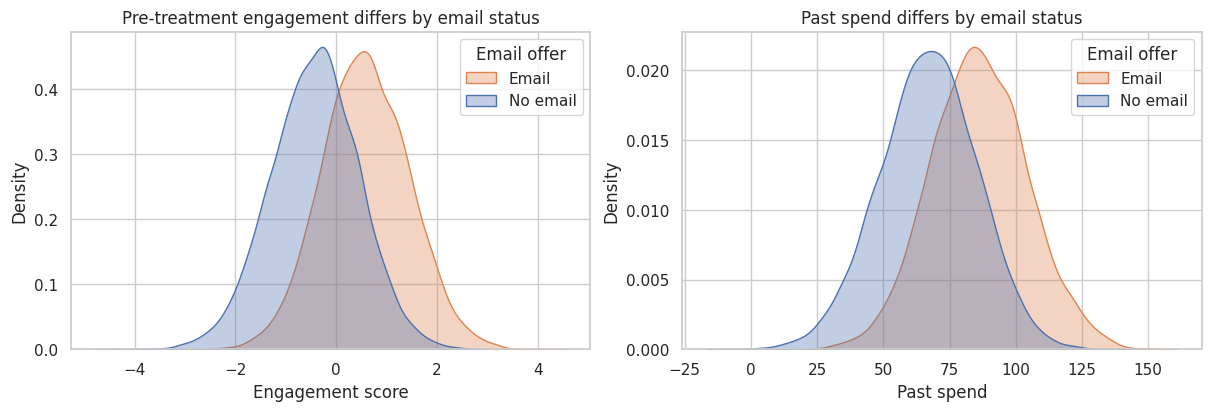

In [7]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.kdeplot(
    data=customers,
    x="engagement",
    hue="email_offer",
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Pre-treatment engagement differs by email status")
axes[0].set_xlabel("Engagement score")
axes[0].legend(title="Email offer", labels=["Email", "No email"])

sns.kdeplot(
    data=customers,
    x="past_spend",
    hue="email_offer",
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[1],
)
axes[1].set_title("Past spend differs by email status")
axes[1].set_xlabel("Past spend")
axes[1].legend(title="Email offer", labels=["Email", "No email"])

plt.show()


The distributions are shifted. The email group contains more high-engagement and high-spend customers. These are pre-treatment variables, meaning they existed before the email decision.

That matters because pre-treatment variables can affect both treatment assignment and the outcome. When a variable affects both, it is a candidate confounder. Later lectures will formalize this with DAGs, potential outcomes, propensity scores, and adjustment criteria.

For now, the lesson is simpler: before estimating anything, ask whether the treated and comparison groups were generated by a process that makes them comparable for the causal question.

## 4. Estimand, Estimator, Estimate

Causal inference becomes much clearer when we separate three words that are often blurred together.

| Term | Meaning | Example in this simulation |
|---|---|---|
| Estimand | The target causal quantity we want to learn | Average effect of email versus no email on 30-day profit |
| Estimator | The rule or procedure used to estimate the estimand | Difference in means, regression adjustment, inverse probability weighting |
| Estimate | The number produced by applying the estimator to data | The observed difference or regression coefficient |

The estimand is a property of the question. The estimator is a property of the method. The estimate is a property of the particular dataset.

A common applied failure mode is to start with an estimator, such as "run a regression" or "fit a causal forest," before defining the estimand. In this course, we will try to move in the opposite order:

1. question;
2. estimand;
3. identification assumptions;
4. estimator;
5. estimate;
6. decision.


In [8]:
# Fit the statistical model and collect estimates used in the following interpretation.
naive_model = smf.ols("thirty_day_profit ~ email_offer", data=customers).fit()
adjusted_model = smf.ols(
    "thirty_day_profit ~ email_offer + engagement + past_spend + support_contacts",
    data=customers,
).fit()

comparison = pd.DataFrame(
    {
        "target_or_method": [
            "True ATE: E[Y(1) - Y(0)]",
            "Naive difference in observed means",
            "OLS coefficient without pre-treatment controls",
            "OLS coefficient with pre-treatment controls",
        ],
        "value": [
            true_ate,
            naive_difference,
            naive_model.params["email_offer"],
            adjusted_model.params["email_offer"],
        ],
    }
)
smart_display(comparison)


,target_or_method,value
0,True ATE: E[Y(1) - Y(0)],6.000
1,Naive difference in observed means,22.241
2,OLS coefficient without pre-treatment controls,22.241
3,OLS coefficient with pre-treatment controls,5.797


The regression without controls reproduces the naive observed difference. It is just a model-based way of comparing the treated and untreated groups.

The adjusted regression is much closer to the true effect because, in this simulation, we measured the variables that jointly drive email assignment and profit. That does **not** mean regression adjustment always works. It works here because the simulation was built to satisfy a favorable set of assumptions:

- the relevant confounders were observed;
- the relationship between the controls and the outcome was simple enough for the model;
- every type of customer had a nonzero chance of receiving or not receiving the email;
- one customer's email status did not change another customer's outcome.

Those assumptions will become central later. In this first lecture, the important point is that a causal question cannot be answered from the outcome and treatment columns alone unless the data-generating process gives us a reason to treat the comparison as fair.

## 5. Randomization as a Clean Answer to a Causal Question

Randomization is powerful because it breaks the systematic link between treatment assignment and pre-treatment attributes. If customers are randomly assigned to email or no email, then the treated and untreated groups should be similar on average before treatment.

Let's reuse the same customers and same potential outcomes, but assign the email randomly.


In [9]:
# Build the summary table used to connect the calculation back to the design question.
rng_randomized = np.random.default_rng(2026)
randomized_customers = customers.copy()
randomized_customers["email_offer"] = rng_randomized.binomial(n=1, p=0.5, size=len(customers))
randomized_customers["thirty_day_profit"] = np.where(
    randomized_customers["email_offer"] == 1,
    randomized_customers["_potential_profit_email"],
    randomized_customers["_potential_profit_no_email"],
)

randomized_difference = (
    randomized_customers.loc[randomized_customers["email_offer"] == 1, "thirty_day_profit"].mean()
    - randomized_customers.loc[randomized_customers["email_offer"] == 0, "thirty_day_profit"].mean()
)

balance_observational = (
    customers.groupby("email_offer")[["engagement", "past_spend", "support_contacts"]]
    .mean()
    .diff()
    .iloc[-1]
)
balance_randomized = (
    randomized_customers.groupby("email_offer")[["engagement", "past_spend", "support_contacts"]]
    .mean()
    .diff()
    .iloc[-1]
)

balance = pd.DataFrame(
    {
        "observational_email_minus_no_email": balance_observational,
        "randomized_email_minus_no_email": balance_randomized,
    }
)
smart_display(balance)


,observational_email_minus_no_email,randomized_email_minus_no_email
engagement,1.013,-0.006
past_spend,19.213,-0.188
support_contacts,0.318,-0.013


In Randomization as a Clean Answer to a Causal Question, the table keeps the counterfactual gap in view. The table is useful because it separates observed outcomes from the counterfactual comparison we actually want.

In [10]:
pd.DataFrame(
    {
        "setting": ["Original observational assignment", "Randomized assignment"],
        "difference_in_mean_profit": [naive_difference, randomized_difference],
        "true_ate": [true_ate, true_ate],
    }
)


,setting,difference_in_mean_profit,true_ate
0,Original observational assignment,22.241,6.0
1,Randomized assignment,5.835,6.0


The randomized assignment nearly eliminates the pre-treatment differences between groups. The resulting difference in mean profit is close to the true effect.

This is the intuition behind randomized experiments and A/B tests. Randomization gives a credible assignment mechanism: before treatment, the groups differ only by chance. Because treatment assignment is not based on engagement, past spend, support history, or other customer traits, the simple treated-versus-control comparison can estimate the causal effect.

Most of this course is about what to do when randomization is impossible, incomplete, expensive, unethical, underpowered, contaminated, or historically unavailable. But the randomized experiment remains the conceptual benchmark.

## 6. What Makes a Good Industry Causal Question?

A good industry causal question is not merely statistically precise. It is decision-ready.

Use this checklist before modeling:

1. **Actionable treatment**: Is the treatment something the organization could actually change?
2. **Clear comparison**: Is the counterfactual alternative explicit?
3. **Defined population**: Are the eligible units clear?
4. **Meaningful outcome**: Does the outcome connect to the decision, not just a convenient proxy?
5. **Time zero and horizon**: Do we know when follow-up starts and ends?
6. **Estimand**: Are we targeting an average effect, subgroup effect, treatment-on-treated effect, policy value, or something else?
7. **Assignment story**: Why did some units receive treatment and others not?
8. **Credible assumptions**: What would need to be true for the planned comparison to be causal?
9. **Decision threshold**: How large must the effect be to change the decision?
10. **Risks and guardrails**: What unintended outcomes might change?

If these pieces are missing, the problem is not ready for an estimator yet.


| component | diagnostic_question |
|---|---|
| Treatment | Can the business assign, launch, remove, price, target, rank, message, or expose something? |
| Comparison | What would happen instead: no treatment, old policy, lower dose, delayed launch, or alternative model? |
| Population | Which units are eligible, and which are out of scope? |
| Outcome | What metric captures value, harm, cost, quality, or risk? |
| Timing | When does assignment happen, and when is the outcome measured? |
| Estimand | Is the target an average effect, subgroup effect, effect among treated units, or policy value? |
| Identification | What makes the treated and comparison outcomes comparable? |
| Decision | What action will be taken if the effect is positive, negative, small, or uncertain? |


## 7. Mini Case: Rewriting a Vague Request

Imagine a product leader asks:

> "Can you prove that our AI support assistant improves customer experience?"

That sentence is not yet a causal question. It contains a desired conclusion, an ambiguous treatment, an undefined comparison, and an undefined outcome.

A better causal question would be:

> Among tier-1 support tickets created by logged-in customers, what is the average effect of routing the ticket through the LLM-assisted drafting workflow versus the existing human-only workflow on time to first resolution, customer satisfaction, escalation rate, and reopened-ticket rate measured over 14 days after ticket creation?

This version is not just more formal. It is more useful. It tells the team what data must exist, what assignment process matters, what guardrails to monitor, and what decision the analysis can support.


In [12]:
# Prepare the quantities used in the Mini Case: Rewriting a Vague Request discussion.
ai_support_question = causal_question_card(
    population="tier-1 support tickets from logged-in customers",
    treatment="routing the ticket through the LLM-assisted drafting workflow",
    comparison="routing the ticket through the existing human-only workflow",
    outcome="time to first resolution, customer satisfaction, escalation rate, and reopened-ticket rate",
    horizon="14 days after ticket creation",
    estimand="average effect",
    decision="decide whether to expand, revise, or pause the AI support workflow",
)

ai_support_question.T.rename(columns={0: "AI support example"})


,AI support example
population,tier-1 support tickets from logged-in customers
treatment,routing the ticket through the LLM-assisted drafting workflow
comparison,routing the ticket through the existing human-only workflow
outcome,"time to first resolution, customer satisfaction, escalation rate, and reopened-ticket rate"
horizon,14 days after ticket creation
estimand,average effect
decision,"decide whether to expand, revise, or pause the AI support workflow"
causal_question,"Among tier-1 support tickets from logged-in customers, what is the average effect of routin..."


Notice that this causal question includes guardrails. A workflow that reduces time to first resolution but increases escalations or reopened tickets may not be a good product decision.

Industry causal inference often involves more than one outcome:

- a primary value metric;
- operational cost metrics;
- customer experience metrics;
- safety, quality, fairness, or risk guardrails.

The causal question should make the tradeoff visible before the analysis starts.

## 8. Key Takeaways

1. A causal question is about the effect of an intervention relative to a comparison.
2. Descriptive and predictive questions can be valuable without being causal.
3. A useful causal question specifies the unit, population, treatment, comparison, outcome, time horizon, estimand, and decision.
4. Observed treated-versus-untreated differences can be badly biased when treatment assignment is related to pre-treatment characteristics.
5. Randomization is the clean benchmark because it makes treated and untreated groups comparable on average before treatment.
6. In observational causal inference, the hardest work is often defending why a non-randomized comparison can approximate the causal comparison we actually want.

## Preview of the Next Lecture

The next lecture separates prediction from causal inference more explicitly. We will see why a model can predict outcomes well and still answer the wrong question for intervention decisions.


## References

- Gelman, A., & Imbens, G. W. (2013). *Why ask Why? Forward causal inference and reverse causal questions*. National Bureau of Economic Research. https://doi.org/10.3386/w19614. Access: open working paper / DOI page.
- Hernán, M. A., & Robins, J. M. (2016). Using big data to emulate a target trial when a randomized trial is not available. *American Journal of Epidemiology, 183*(8), 758-764. https://doi.org/10.1093/aje/kwv254. Access: publisher / DOI page.
- Holland, P. W. (1986). Statistics and causal inference. *Journal of the American Statistical Association, 81*(396), 945-960. https://doi.org/10.1080/01621459.1986.10478354. Access: publisher / DOI page.
- Pearl, J. (1995). Causal diagrams for empirical research. *Biometrika, 82*(4), 669-688. https://doi.org/10.2307/2337329. Access: publisher / DOI page.
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology, 66*(5), 688-701. https://doi.org/10.1037/h0037350. Access: publisher / DOI page.
